2026-02-05 RecSys Frontier Toy Example

- created by Jihyun Choi
- created at 2026-02-02

- wiki : 




## Table of Contents

1. 50개 게임 카탈로그 생성 (5개 장르 × 3개 플랫폼)
2. RQ-VAE 훈련 → Semantic IDs 생성
3. Codebook 품질 분석 (utilization, genre clustering)
4. User sequences 생성 (20명 사용자 × 평균 8개 아이템)
5. SASRec 훈련 → Next-item prediction
6. 추천 데모 (input sequence → predicted semantic ID)
7. 시각화 (training curves, t-SNE plot)

## 0. 패키지 로드

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# 재현성을 위한 시드 고정
torch.manual_seed(20260205)
np.random.seed(20260205)

print("🎮 Semantic IDs Toy Example for RecSys Frontier")
print("=" * 60)

🎮 Semantic IDs Toy Example for RecSys Frontier


## 1. 데이터 생성

In [2]:

class ToyGameCatalog:
    """
    간단한 게임 카탈로그 생성
    - 50개 게임
    - 5개 장르: Action, RPG, Puzzle, Sports, Strategy
    - 3개 플랫폼: PC, Console, Mobile
    """
    
    def __init__(self, n_items=50):
        self.n_items = n_items
        self.genres = ['Action', 'RPG', 'Puzzle', 'Sports', 'Strategy']
        self.platforms = ['PC', 'Console', 'Mobile']
        
        # 게임 메타데이터 생성
        self.items = []
        for i in range(n_items):
            genre = self.genres[i % len(self.genres)]
            platform = self.platforms[i % len(self.platforms)]
            
            item = {
                'id': i,
                'title': f"Game_{i}",
                'genre': genre,
                'platform': platform,
                'description': f"A {genre} game for {platform}"
            }
            self.items.append(item)
    
    def create_embeddings(self, embed_dim=64):
        """
        간단한 one-hot 기반 임베딩 생성 (실제로는 BERT 등 사용)
        """
        embeddings = []
        
        for item in self.items:
            # Genre embedding (5-dim one-hot)
            genre_vec = np.zeros(len(self.genres))
            genre_vec[self.genres.index(item['genre'])] = 1.0
            
            # Platform embedding (3-dim one-hot)
            platform_vec = np.zeros(len(self.platforms))
            platform_vec[self.platforms.index(item['platform'])] = 1.0
            
            # 나머지는 랜덤 (실제로는 description embedding)
            random_vec = np.random.randn(embed_dim - 8) * 0.1
            
            # 결합
            full_embedding = np.concatenate([genre_vec, platform_vec, random_vec])
            embeddings.append(full_embedding)
        
        return np.array(embeddings)

# 카탈로그 생성
catalog = ToyGameCatalog(n_items=50)
item_embeddings = catalog.create_embeddings(embed_dim=64)

print(f"✅ Created catalog with {len(catalog.items)} games")
print(f"   Embedding shape: {item_embeddings.shape}")
print(f"   Example item: {catalog.items[0]}")

✅ Created catalog with 50 games
   Embedding shape: (50, 64)
   Example item: {'id': 0, 'title': 'Game_0', 'genre': 'Action', 'platform': 'PC', 'description': 'A Action game for PC'}


## 2. RQ-VAE 구현 (Simplified)

In [4]:
class SimpleRQVAE(nn.Module):
    """
    Simplified Residual Quantized VAE for Semantic ID generation
    
    Architecture:
    - Encoder: Linear layers (64 -> 32)
    - 2 quantization levels (실제는 3-4 levels)
    - Each level has 16 codes (실제는 256 codes)
    - Decoder: Linear layers (32 -> 64)
    """
    
    def __init__(self, input_dim=64, hidden_dim=32, n_levels=2, codebook_size=16):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.n_levels = n_levels
        self.codebook_size = codebook_size
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        
        # Codebooks (각 level마다)
        self.codebooks = nn.ParameterList([
            nn.Parameter(torch.randn(codebook_size, hidden_dim) * 0.1)
            for _ in range(n_levels)
        ])
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
        )
        
        self.commitment_weight = 0.5  # Eugene이 찾은 최적값
    
    def quantize(self, z: torch.Tensor, codebook: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Vector quantization
        
        Args:
            z: [batch_size, hidden_dim]
            codebook: [codebook_size, hidden_dim]
        
        Returns:
            quantized: [batch_size, hidden_dim]
            indices: [batch_size]
        """
        # z와 codebook 간 거리 계산
        distances = torch.cdist(z, codebook)  # [batch, codebook_size]
        
        # 가장 가까운 code 선택
        indices = torch.argmin(distances, dim=1)  # [batch]
        
        # Quantized vector
        quantized = codebook[indices]  # [batch, hidden_dim]
        
        return quantized, indices
    
    def forward(self, x: torch.Tensor) -> Dict:
        """
        Forward pass with residual quantization
        
        Args:
            x: [batch_size, input_dim] 원본 embedding
        
        Returns:
            Dict containing:
                - x_reconstructed: 복원된 embedding
                - semantic_ids: [batch_size, n_levels] semantic ID tokens
                - loss: total loss
                - losses: detailed loss breakdown
        """
        batch_size = x.shape[0]
        
        # Encode
        z = self.encoder(x)  # [batch, hidden_dim]
        
        # Residual quantization
        residual = z
        semantic_ids = []
        quantized_levels = []
        
        for level, codebook in enumerate(self.codebooks):
            # Quantize current residual
            q, indices = self.quantize(residual, codebook)
            
            semantic_ids.append(indices)
            quantized_levels.append(q)
            
            # Update residual
            residual = residual - q
        
        # Sum all quantized levels
        z_quantized = sum(quantized_levels)
        
        # Decode
        x_reconstructed = self.decoder(z_quantized)
        
        # Loss calculation
        recon_loss = F.mse_loss(x, x_reconstructed)
        
        # Quantization loss (codebook + commitment)
        vq_loss = 0.0
        residual = z
        for level, codebook in enumerate(self.codebooks):
            q, _ = self.quantize(residual, codebook)
            
            # Codebook loss (stop gradient on residual)
            codebook_loss = F.mse_loss(residual.detach(), q)
            
            # Commitment loss (stop gradient on quantized)
            commitment_loss = F.mse_loss(residual, q.detach())
            
            vq_loss += codebook_loss + self.commitment_weight * commitment_loss
            
            residual = residual - q
        
        total_loss = recon_loss + vq_loss
        
        # Semantic IDs를 tensor로 변환
        semantic_ids_tensor = torch.stack(semantic_ids, dim=1)  # [batch, n_levels]
        
        return {
            'x_reconstructed': x_reconstructed,
            'semantic_ids': semantic_ids_tensor,
            'loss': total_loss,
            'losses': {
                'reconstruction': recon_loss.item(),
                'vq': vq_loss.item(),
                'total': total_loss.item()
            }
        }
    
    def encode_to_semantic_ids(self, x: torch.Tensor) -> torch.Tensor:
        """Encode embeddings to semantic IDs (inference mode)"""
        with torch.no_grad():
            z = self.encoder(x)
            
            semantic_ids = []
            residual = z
            
            for codebook in self.codebooks:
                _, indices = self.quantize(residual, codebook)
                semantic_ids.append(indices)
                
                q = codebook[indices]
                residual = residual - q
            
            return torch.stack(semantic_ids, dim=1)

## 4. RQ-VAE 훈련

In [5]:

print("\n" + "=" * 60)
print("🔧 Training RQ-VAE to generate Semantic IDs")
print("=" * 60)

# 데이터 준비
item_embeddings_tensor = torch.FloatTensor(item_embeddings)

# 모델 초기화
rqvae = SimpleRQVAE(
    input_dim=64,
    hidden_dim=32,
    n_levels=2,
    codebook_size=16
)

# Optimizer
optimizer = torch.optim.Adam(rqvae.parameters(), lr=1e-3)

# Training loop
n_epochs = 100
batch_size = 16

print(f"Training settings:")
print(f"  - Epochs: {n_epochs}")
print(f"  - Batch size: {batch_size}")
print(f"  - Commitment weight β: {rqvae.commitment_weight}")
print()

losses_history = {'reconstruction': [], 'vq': [], 'total': []}

for epoch in range(n_epochs):
    # Shuffle data
    perm = torch.randperm(len(item_embeddings_tensor))
    shuffled_data = item_embeddings_tensor[perm]
    
    epoch_losses = defaultdict(float)
    n_batches = 0
    
    for i in range(0, len(shuffled_data), batch_size):
        batch = shuffled_data[i:i+batch_size]
        
        # Forward pass
        output = rqvae(batch)
        loss = output['loss']
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Record losses
        for k, v in output['losses'].items():
            epoch_losses[k] += v
        n_batches += 1
    
    # Average losses
    for k in epoch_losses:
        epoch_losses[k] /= n_batches
        losses_history[k].append(epoch_losses[k])
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Total: {epoch_losses['total']:.4f} | "
              f"Recon: {epoch_losses['reconstruction']:.4f} | "
              f"VQ: {epoch_losses['vq']:.4f}")



🔧 Training RQ-VAE to generate Semantic IDs
Training settings:
  - Epochs: 100
  - Batch size: 16
  - Commitment weight β: 0.5

Epoch  20 | Total: 0.0440 | Recon: 0.0332 | VQ: 0.0108
Epoch  40 | Total: 0.0352 | Recon: 0.0314 | VQ: 0.0038
Epoch  60 | Total: 0.0328 | Recon: 0.0310 | VQ: 0.0017
Epoch  80 | Total: 0.0320 | Recon: 0.0310 | VQ: 0.0010
Epoch 100 | Total: 0.0307 | Recon: 0.0297 | VQ: 0.0010


## 5. Semantic IDs 생성 및 분석

In [8]:
print("\n" + "=" * 60)
print("🎯 Generating Semantic IDs for all items")
print("=" * 60)

# 모든 아이템의 semantic IDs 생성
semantic_ids_all = rqvae.encode_to_semantic_ids(item_embeddings_tensor)
semantic_ids_np = semantic_ids_all.numpy()

print(f"Generated semantic IDs shape: {semantic_ids_np.shape}")
print(f"  (n_items, n_levels) = ({semantic_ids_np.shape[0]}, {semantic_ids_np.shape[1]})")
print()

# Semantic ID 예시 출력
print("Example Semantic IDs:")
for i in range(5):
    item = catalog.items[i]
    sid = semantic_ids_np[i]
    print(f"  {item['title']:12s} ({item['genre']:8s}, {item['platform']:7s}) → "
          f"<sid_{sid[0]:2d}><sid_{sid[1]:2d}>")



🎯 Generating Semantic IDs for all items
Generated semantic IDs shape: (50, 2)
  (n_items, n_levels) = (50, 2)

Example Semantic IDs:
  Game_0       (Action  , PC     ) → <sid_12><sid_ 7>
  Game_1       (RPG     , Console) → <sid_12><sid_ 7>
  Game_2       (Puzzle  , Mobile ) → <sid_12><sid_ 7>
  Game_3       (Sports  , PC     ) → <sid_12><sid_ 7>
  Game_4       (Strategy, Console) → <sid_12><sid_ 7>


## 6. Semantic IDs 품질 분석

In [7]:
print("\n" + "=" * 60)
print("📊 Analyzing Semantic ID Quality")
print("=" * 60)

# 6.1 Codebook utilization
print("\n1. Codebook Utilization (고른 분포일수록 좋음):")
for level in range(rqvae.n_levels):
    level_codes = semantic_ids_np[:, level]
    unique_codes = len(np.unique(level_codes))
    print(f"   Level {level}: {unique_codes}/{rqvae.codebook_size} codes used "
          f"({100*unique_codes/rqvae.codebook_size:.1f}%)")

# 6.2 Genre별 Semantic ID 분포
print("\n2. Genre Clustering (같은 장르가 비슷한 ID를 가지는가?):")
genre_to_ids = defaultdict(list)
for i, item in enumerate(catalog.items):
    genre = item['genre']
    sid = tuple(semantic_ids_np[i])
    genre_to_ids[genre].append(sid)

for genre in catalog.genres:
    ids = genre_to_ids[genre]
    # Level 0만 보기
    level0_ids = [sid[0] for sid in ids]
    unique_l0 = len(set(level0_ids))
    print(f"   {genre:10s}: {unique_l0} distinct level-0 IDs (out of {len(ids)} items)")

# 6.3 Unique IDs
unique_ids = len(set(map(tuple, semantic_ids_np)))
print(f"\n3. Unique Semantic IDs: {unique_ids}/{len(catalog.items)} "
      f"({100*unique_ids/len(catalog.items):.1f}%)")


📊 Analyzing Semantic ID Quality

1. Codebook Utilization (고른 분포일수록 좋음):
   Level 0: 2/16 codes used (12.5%)
   Level 1: 1/16 codes used (6.2%)

2. Genre Clustering (같은 장르가 비슷한 ID를 가지는가?):
   Action    : 2 distinct level-0 IDs (out of 10 items)
   RPG       : 1 distinct level-0 IDs (out of 10 items)
   Puzzle    : 2 distinct level-0 IDs (out of 10 items)
   Sports    : 2 distinct level-0 IDs (out of 10 items)
   Strategy  : 1 distinct level-0 IDs (out of 10 items)

3. Unique Semantic IDs: 2/50 (4.0%)


## 7. User Sequence 생성 (행동 데이터)

In [9]:
print("\n" + "=" * 60)
print("👤 Generating User Interaction Sequences")
print("=" * 60)

def generate_user_sequences(catalog, n_users=20, avg_length=8):
    """
    사용자별 interaction sequence 생성
    - 같은 장르를 선호하는 경향 시뮬레이션
    """
    sequences = []
    
    for user_id in range(n_users):
        # 사용자별 선호 장르 (1-2개)
        preferred_genres = np.random.choice(catalog.genres, size=2, replace=False)
        
        # Sequence 길이
        seq_len = np.random.randint(5, avg_length + 3)
        
        sequence = []
        for _ in range(seq_len):
            # 80% 확률로 선호 장르, 20% 랜덤
            if np.random.rand() < 0.8:
                genre = np.random.choice(preferred_genres)
                # 해당 장르의 아이템 중 랜덤 선택
                genre_items = [i for i, item in enumerate(catalog.items) 
                              if item['genre'] == genre]
                item_id = np.random.choice(genre_items)
            else:
                item_id = np.random.randint(0, len(catalog.items))
            
            sequence.append(item_id)
        
        sequences.append(sequence)
    
    return sequences

# Sequence 생성
user_sequences = generate_user_sequences(catalog, n_users=20, avg_length=8)

print(f"Generated {len(user_sequences)} user sequences")
print(f"  Avg length: {np.mean([len(s) for s in user_sequences]):.1f}")
print()

# 예시 출력
print("Example sequences (item IDs):")
for i in range(3):
    seq = user_sequences[i]
    genres = [catalog.items[item_id]['genre'] for item_id in seq]
    print(f"  User {i}: {seq[:5]}... → Genres: {genres[:5]}...")

# Semantic ID sequences 변환
user_sequences_semantic = []
for seq in user_sequences:
    semantic_seq = [tuple(semantic_ids_np[item_id]) for item_id in seq]
    user_sequences_semantic.append(semantic_seq)


👤 Generating User Interaction Sequences
Generated 20 user sequences
  Avg length: 8.2

Example sequences (item IDs):
  User 0: [np.int64(6), np.int64(18), np.int64(28), np.int64(8), np.int64(11)]... → Genres: ['RPG', 'Sports', 'Sports', 'Sports', 'RPG']...
  User 1: [np.int64(34), np.int64(25), 44, np.int64(45), np.int64(40)]... → Genres: ['Strategy', 'Action', 'Strategy', 'Action', 'Action']...
  User 2: [np.int64(43), np.int64(18), np.int64(3), np.int64(33), np.int64(32)]... → Genres: ['Sports', 'Sports', 'Sports', 'Sports', 'Puzzle']...


## 8. Simplified SASRec (Next-item Prediction)

In [10]:
print("\n" + "=" * 60)
print("Training Simplified SASRec on Semantic IDs")
print("=" * 60)

class SimpleSASRec(nn.Module):
    """
    Simplified Self-Attentive Sequential Recommendation
    - Input: sequence of semantic IDs
    - Output: next semantic ID prediction
    """
    
    def __init__(self, n_tokens=16, n_levels=2, embed_dim=32, hidden_dim=64, n_heads=2):
        super().__init__()
        self.n_tokens = n_tokens
        self.n_levels = n_levels
        self.embed_dim = embed_dim
        
        # Token embeddings (각 level별)
        self.token_embeddings = nn.ModuleList([
            nn.Embedding(n_tokens, embed_dim)
            for _ in range(n_levels)
        ])
        
        # Position embedding
        self.max_seq_len = 20
        self.pos_embedding = nn.Embedding(self.max_seq_len, n_levels * embed_dim)
        
        # Transformer block
        self.attention = nn.MultiheadAttention(
            embed_dim=n_levels * embed_dim,
            num_heads=n_heads,
            batch_first=True
        )
        self.norm1 = nn.LayerNorm(n_levels * embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(n_levels * embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_levels * embed_dim)
        )
        self.norm2 = nn.LayerNorm(n_levels * embed_dim)
        
        # Output heads (각 level별 예측)
        self.output_heads = nn.ModuleList([
            nn.Linear(n_levels * embed_dim, n_tokens)
            for _ in range(n_levels)
        ])
    
    def forward(self, input_ids: torch.Tensor) -> Dict:
        """
        Args:
            input_ids: [batch, seq_len, n_levels]
        
        Returns:
            logits for each level
        """
        batch_size, seq_len, _ = input_ids.shape
        
        # Embed each level
        level_embeds = []
        for level in range(self.n_levels):
            level_tokens = input_ids[:, :, level]  # [batch, seq_len]
            level_embed = self.token_embeddings[level](level_tokens)  # [batch, seq_len, embed_dim]
            level_embeds.append(level_embed)
        
        # Concatenate levels
        x = torch.cat(level_embeds, dim=-1)  # [batch, seq_len, n_levels * embed_dim]
        
        # Add positional encoding
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
        x = x + self.pos_embedding(positions)
        
        # Self-attention
        attn_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool().to(x.device)
        attn_output, _ = self.attention(x, x, x, attn_mask=attn_mask)
        x = self.norm1(x + attn_output)
        
        # FFN
        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)
        
        # Predict next item (use last position)
        last_hidden = x[:, -1, :]  # [batch, n_levels * embed_dim]
        
        # Level-wise prediction
        logits = {}
        for level in range(self.n_levels):
            logits[f'level_{level}'] = self.output_heads[level](last_hidden)
        
        return logits

# Dataset 준비
class SemanticIDSequenceDataset(Dataset):
    def __init__(self, sequences, seq_len=10):
        self.sequences = sequences
        self.seq_len = seq_len
        self.samples = self._prepare_samples()
    
    def _prepare_samples(self):
        samples = []
        for seq in self.sequences:
            if len(seq) < 2:
                continue
            for i in range(1, len(seq)):
                # Input: seq[max(0, i-seq_len):i]
                # Target: seq[i]
                input_seq = seq[max(0, i - self.seq_len):i]
                target = seq[i]
                
                # Padding if needed
                if len(input_seq) < self.seq_len:
                    padding = [(0, 0)] * (self.seq_len - len(input_seq))
                    input_seq = padding + input_seq
                
                samples.append((input_seq, target))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        input_seq, target = self.samples[idx]
        
        input_tensor = torch.LongTensor(input_seq)
        target_tensor = torch.LongTensor(target)
        
        return input_tensor, target_tensor

# Dataset & DataLoader
train_dataset = SemanticIDSequenceDataset(user_sequences_semantic, seq_len=5)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

print(f"Training dataset: {len(train_dataset)} samples")

# Model
sasrec = SimpleSASRec(
    n_tokens=16,
    n_levels=2,
    embed_dim=32,
    hidden_dim=64,
    n_heads=2
)

# Training
optimizer = torch.optim.Adam(sasrec.parameters(), lr=1e-3)
n_epochs = 30

print(f"Training SASRec for {n_epochs} epochs...")
print()

for epoch in range(n_epochs):
    sasrec.train()
    total_loss = 0.0
    
    for input_seq, target in train_loader:
        # Forward
        logits = sasrec(input_seq)
        
        # Loss (각 level별 cross-entropy)
        loss = 0.0
        for level in range(sasrec.n_levels):
            level_logits = logits[f'level_{level}']
            level_target = target[:, level]
            loss += F.cross_entropy(level_logits, level_target)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f}")


Training Simplified SASRec on Semantic IDs
Training dataset: 144 samples
Training SASRec for 30 epochs...

Epoch 10 | Loss: 0.3340
Epoch 20 | Loss: 0.3069
Epoch 30 | Loss: 0.2784


## 9. 추천 생성 및 데모

In [11]:
print("\n" + "=" * 60)
print("Generating Recommendations (Demo)")
print("=" * 60)

def recommend_next_item(sasrec, input_sequence, catalog, semantic_ids_np, top_k=3):
    """
    주어진 sequence에서 다음 아이템 추천
    """
    sasrec.eval()
    
    # Convert to semantic IDs
    input_semantic = [tuple(semantic_ids_np[item_id]) for item_id in input_sequence]
    
    # Padding
    seq_len = 5
    if len(input_semantic) < seq_len:
        padding = [(0, 0)] * (seq_len - len(input_semantic))
        input_semantic = padding + input_semantic
    else:
        input_semantic = input_semantic[-seq_len:]
    
    # To tensor
    input_tensor = torch.LongTensor([input_semantic])  # [1, seq_len, n_levels]
    
    with torch.no_grad():
        logits = sasrec(input_tensor)
        
        # Greedy decoding: pick most likely token at each level
        predicted_sid = []
        for level in range(sasrec.n_levels):
            level_logits = logits[f'level_{level}'][0]  # [n_tokens]
            predicted_token = torch.argmax(level_logits).item()
            predicted_sid.append(predicted_token)
        
        predicted_sid = tuple(predicted_sid)
    
    # Find matching items
    matching_items = []
    for item_id, sid in enumerate(semantic_ids_np):
        if tuple(sid) == predicted_sid:
            matching_items.append(item_id)
    
    return matching_items, predicted_sid

# Demo
test_sequence = [0, 5, 10, 15]  # Action 게임들

print("Input sequence:")
for item_id in test_sequence:
    item = catalog.items[item_id]
    print(f"  - {item['title']} ({item['genre']}, {item['platform']})")

matching_items, predicted_sid = recommend_next_item(
    sasrec, test_sequence, catalog, semantic_ids_np
)

print(f"\nPredicted Semantic ID: <sid_{predicted_sid[0]}><sid_{predicted_sid[1]}>")
print(f"\nRecommended items:")
if matching_items:
    for item_id in matching_items[:3]:
        item = catalog.items[item_id]
        print(f"  ✅ {item['title']} ({item['genre']}, {item['platform']})")
else:
    print("  (No exact match found - this is expected in toy example)")



Generating Recommendations (Demo)
Input sequence:
  - Game_0 (Action, PC)
  - Game_5 (Action, Mobile)
  - Game_10 (Action, Console)
  - Game_15 (Action, PC)

Predicted Semantic ID: <sid_12><sid_7>

Recommended items:
  ✅ Game_0 (Action, PC)
  ✅ Game_1 (RPG, Console)
  ✅ Game_2 (Puzzle, Mobile)


## 10. 시각화


Visualizations
✅ Saved: semantic_ids_training.png

Generating t-SNE visualization...
✅ Saved: semantic_ids_tsne.png


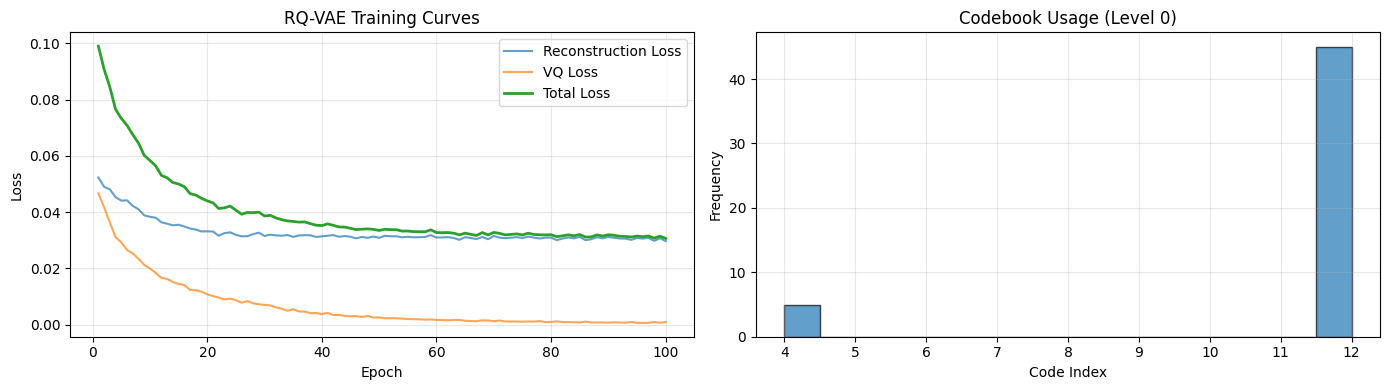

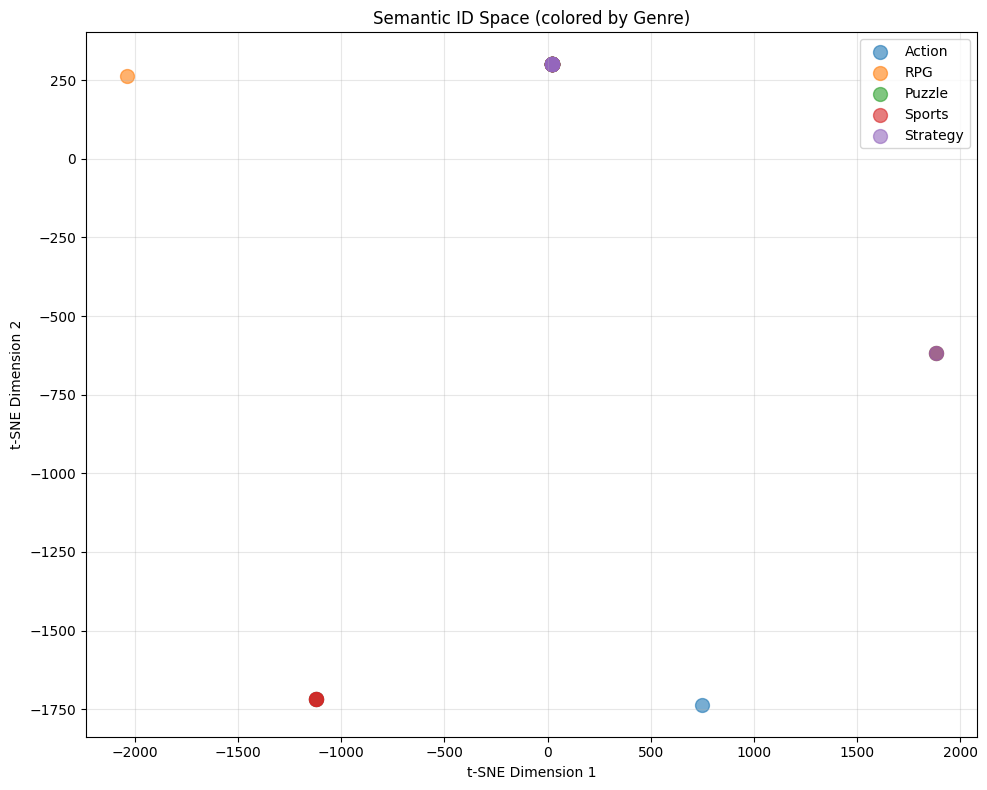

In [13]:
print("\n" + "=" * 60)
print("Visualizations")
print("=" * 60)

# 10.1 Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RQ-VAE losses
ax = axes[0]
epochs = range(1, len(losses_history['total']) + 1)
ax.plot(epochs, losses_history['reconstruction'], label='Reconstruction Loss', alpha=0.7)
ax.plot(epochs, losses_history['vq'], label='VQ Loss', alpha=0.7)
ax.plot(epochs, losses_history['total'], label='Total Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('RQ-VAE Training Curves')
ax.legend()
ax.grid(alpha=0.3)

# Codebook usage histogram
ax = axes[1]
level0_codes = semantic_ids_np[:, 0]
ax.hist(level0_codes, bins=rqvae.codebook_size, alpha=0.7, edgecolor='black')
ax.set_xlabel('Code Index')
ax.set_ylabel('Frequency')
ax.set_title('Codebook Usage (Level 0)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('semantic_ids_training.png', dpi=150, bbox_inches='tight')
print("✅ Saved: semantic_ids_training.png")

# 10.2 Semantic ID space visualization (t-SNE)
from sklearn.manifold import TSNE

print("\nGenerating t-SNE visualization...")

# Reconstruct embeddings from semantic IDs
with torch.no_grad():
    # Get quantized representations
    z = rqvae.encoder(item_embeddings_tensor)
    
    quantized_sum = torch.zeros_like(z)
    residual = z
    
    for level, codebook in enumerate(rqvae.codebooks):
        q, _ = rqvae.quantize(residual, codebook)
        quantized_sum += q
        residual = residual - q
    
    reconstructed = rqvae.decoder(quantized_sum).numpy()

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
embeddings_2d = tsne.fit_transform(reconstructed)

# Plot by genre
fig, ax = plt.subplots(figsize=(10, 8))

for i, genre in enumerate(catalog.genres):
    genre_indices = [j for j, item in enumerate(catalog.items) if item['genre'] == genre]
    genre_embeddings = embeddings_2d[genre_indices]
    
    ax.scatter(genre_embeddings[:, 0], genre_embeddings[:, 1], 
              label=genre, alpha=0.6, s=100)

ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_title('Semantic ID Space (colored by Genre)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('semantic_ids_tsne.png', dpi=150, bbox_inches='tight')
print("✅ Saved: semantic_ids_tsne.png")

plt.show()